In [1]:
# shap_autoencoder.ipynb
# SHAP on Autoencoder model
# Using KernelExplainer (Same as CNN)

import numpy as np
import pandas as pd
import shap
import tensorflow as tf
import matplotlib.pyplot as plt
import json
import time

print(f"TensorFlow: {tf.__version__}")
print(f"SHAP: {shap.__version__}")
print("Libraries imported!")

2026-04-07 17:24:26.749440: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.16.2
SHAP: 0.49.1
Libraries imported!


In [7]:
# Step 2: Load data and autoencoder model

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Load data
X_train = np.load(save_path + "X_train.npy")
X_test  = np.load(save_path + "X_test.npy")
y_test  = pd.read_csv(save_path + "y_test.csv").squeeze()

# Load autoencoder
ae_model = tf.keras.models.load_model(save_path + "ae_model.keras")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")
print("Autoencoder loaded!")
ae_model.summary()

X_train: (1979513, 80)
X_test:  (848363, 80)
y_test:  (848363,)
Autoencoder loaded!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 80)             │         2,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,914 (73.89 KB)

 Trainable params: 6,304 (24.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,610 (49.26 KB)

In [12]:
# Step 3: Prepare SHAP for Autoencoder
# Autoencoder is different from RF and CNN!
# We explain RECONSTRUCTION ERROR per sample
# High error = anomaly = attack detected

print("Preparing SHAP for Autoencoder...")

# Small background sample (100 records = faster)
np.random.seed(42)
background_idx = np.random.choice(len(X_train), 100, replace=False)
X_background = X_train[background_idx]

# Small test sample (50 records)
sample_idx = np.random.choice(len(X_test), 50, replace=False)
X_sample = X_test[sample_idx]

# Define prediction function = reconstruction error per sample
def ae_predict(X):
    X_reconstructed = ae_model.predict(X, verbose=0)
    mse = np.mean(np.square(X - X_reconstructed), axis=1)
    return mse

print(f"Background: {X_background.shape}")
print(f"Sample:     {X_sample.shape}")
print("Test prediction function...")
test_output = ae_predict(X_sample[:3])
print(f"Sample MSE values: {test_output}")
print("Ready!")

Preparing SHAP for Autoencoder...
Background: (100, 80)
Sample:     (50, 80)
Test prediction function...
Sample MSE values: [8.88206358e-04 1.59835720e+00 1.23150296e-03]
Ready!


In [24]:
# Step 4: Run SHAP KernelExplainer
# This will take 5-10 minutes

print("Creating SHAP KernelExplainer...")
print("This may take 5-10 minutes, please wait...")

import time
start_time = time.time()

explainer = shap.KernelExplainer(ae_predict, X_background)
shap_values = explainer.shap_values(X_sample, nsamples=100)

end_time = time.time()
shap_time = round(end_time - start_time, 2)

print(f"SHAP complete!")
print(f"Time taken: {shap_time} seconds")
print(f"SHAP values shape: {shap_values.shape}")

Creating SHAP KernelExplainer...
This may take 5-10 minutes, please wait...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP complete!
Time taken: 41.7 seconds
SHAP values shape: (50, 80)


In [22]:
# Step 5: Get exact 80 feature names from original data

path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/cicids_db/*.csv"
files = glob.glob(path)
print(f"Found {len(files)} files")

# Load one file
df_sample = pd.read_csv(files[0], low_memory=False)

# Separate label
X_sample_df = df_sample.drop('Label', axis=1, errors='ignore')
X_sample_df = X_sample_df.drop(' Label', axis=1, errors='ignore')

# Keep only numeric columns (same as preprocessing)
X_numeric = X_sample_df.select_dtypes(include=['float64', 'int64'])
feature_names = X_numeric.columns.tolist()

print(f"Total numeric features: {len(feature_names)}")
print(f"First 5: {feature_names[:5]}")
print(f"Last 5:  {feature_names[-5:]}")

# Save for future use
pd.Series(feature_names).to_csv(save_path + "feature_names.csv", index=False, header=False)
print("Feature names saved!")

Found 8 files
Total numeric features: 80
First 5: [' Source Port', ' Destination Port', ' Protocol', ' Flow Duration', ' Total Fwd Packets']
Last 5:  [' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min']
Feature names saved!


/var/folders/28/cggd8l710jz37nj7nfdl032r0000gn/T/ipykernel_79475/2228479051.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


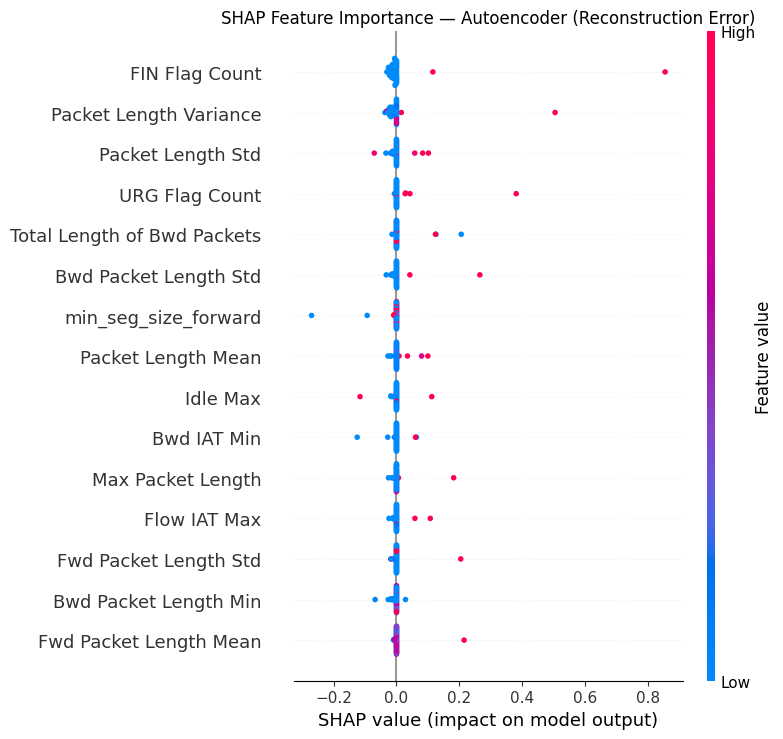

Plot saved with real feature names!
JSON updated with real feature names!

Top 5 features:
  1. FIN Flag Count: 0.027515
  2. Packet Length Variance: 0.019858
  3. Packet Length Std: 0.010165
  4. URG Flag Count: 0.009884
  5. Total Length of Bwd Packets: 0.009454


In [26]:
# Step 6: Replot SHAP with real feature names

# Clean feature names (remove leading spaces)
feature_names_clean = [f.strip() for f in feature_names]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names_clean,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — Autoencoder (Reconstruction Error)")
plt.tight_layout()
plt.savefig(save_path + "shap_ae_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved with real feature names!")

# Update JSON with real feature names
mean_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_shap)[::-1][:10]
top_features = {
    feature_names_clean[i]: round(float(mean_shap[i]), 6) 
    for i in top_idx
}

results = {
    "model": "Autoencoder",
    "xai_method": "SHAP KernelExplainer",
    "sample_size": 50,
    "background_size": 100,
    "shap_time_seconds": shap_time,
    "top_10_features": top_features
}

with open(save_path + "shap_ae_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("JSON updated with real feature names!")
print("\nTop 5 features:")
for i, (k, v) in enumerate(list(top_features.items())[:5]):
    print(f"  {i+1}. {k}: {v}")